In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
DATA_PATH = Path("../data/superstore_clean.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 9800
Columns: 25


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Row ID             9800 non-null   int64  
 1   Order ID           9800 non-null   str    
 2   Order Date         9800 non-null   str    
 3   Ship Date          9800 non-null   str    
 4   Ship Mode          9800 non-null   str    
 5   Customer ID        9800 non-null   str    
 6   Customer Name      9800 non-null   str    
 7   Segment            9800 non-null   str    
 8   Country            9800 non-null   str    
 9   City               9800 non-null   str    
 10  State              9800 non-null   str    
 11  Postal Code        9800 non-null   int64  
 12  Region             9800 non-null   str    
 13  Product ID         9800 non-null   str    
 14  Category           9800 non-null   str    
 15  Sub-Category       9800 non-null   str    
 16  Product Name       9800 non-null   

In [7]:
print("Columns:")
for column in df.columns:
    print("-", column)

Columns:
- Row ID
- Order ID
- Order Date
- Ship Date
- Ship Mode
- Customer ID
- Customer Name
- Segment
- Country
- City
- State
- Postal Code
- Region
- Product ID
- Category
- Sub-Category
- Product Name
- Sales
- year
- month
- day
- trimestre
- Shipping Days
- sales category
- Shipping Category


In [8]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

if len(missing_values) == 0:
    print("No missing values found.")
else:
    print(missing_values)

No missing values found.


In [9]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows}")

Duplicate rows: 0


In [10]:
df.describe()

,Row ID,Postal Code,Sales,year,month,day,trimestre,Shipping Days
count,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000
mean,4900.500000,55241.830612,230.769059,2016.724184,7.818469,15.486837,2.885816,3.961122
std,2829.160653,32037.012522,626.651875,1.123984,3.281905,8.753733,1.057449,1.749614
min,1.000000,1040.000000,0.444000,2015.000000,1.000000,1.000000,1.000000,0.000000
25%,2450.750000,23223.000000,17.248000,2016.000000,5.000000,8.000000,2.000000,3.000000
50%,4900.500000,57551.000000,54.490000,2017.000000,9.000000,16.000000,3.000000,4.000000
75%,7350.250000,90008.000000,210.605000,2018.000000,11.000000,23.000000,4.000000,5.000000
max,9800.000000,99301.000000,22638.480000,2018.000000,12.000000,31.000000,4.000000,7.000000


In [11]:
df.dtypes

Row ID                 int64
Order ID                 str
Order Date               str
Ship Date                str
Ship Mode                str
Customer ID              str
Customer Name            str
Segment                  str
Country                  str
City                     str
State                    str
Postal Code            int64
Region                   str
Product ID               str
Category                 str
Sub-Category             str
Product Name             str
Sales                float64
year                   int64
month                  int64
day                    int64
trimestre              int64
Shipping Days          int64
sales category           str
Shipping Category        str
dtype: object

In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [13]:
print("Total Sales:", round(df["Sales"].sum(), 2))
print("Average Sales:", round(df["Sales"].mean(), 2))
print("Minimum Sales:", round(df["Sales"].min(), 2))
print("Maximum Sales:", round(df["Sales"].max(), 2))

Total Sales: 2261536.78
Average Sales: 230.77
Minimum Sales: 0.44
Maximum Sales: 22638.48


In [14]:
sales_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_category

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

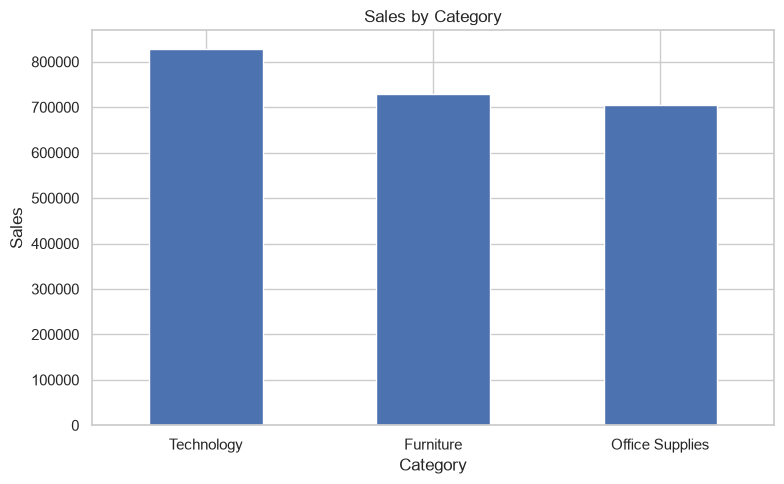

In [15]:
plt.figure(figsize=(8, 5))

sales_category.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
sales_region = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_region

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

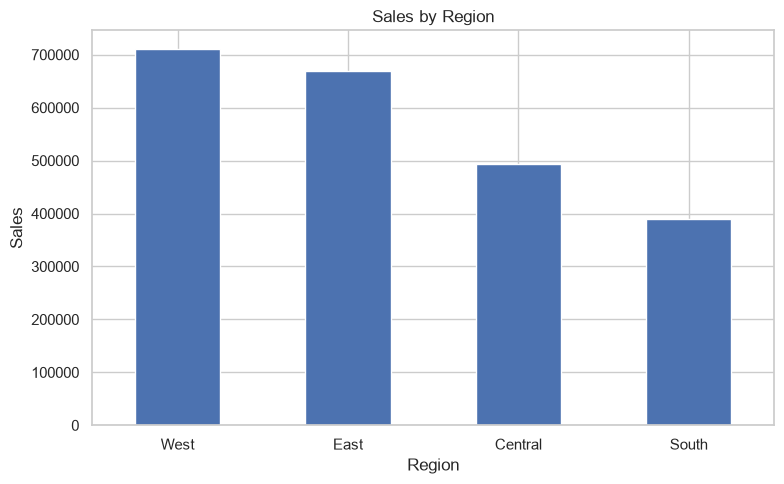

In [17]:
plt.figure(figsize=(8, 5))

sales_region.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
sales_segment = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_segment

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

In [19]:
top_products = (
    df.groupby(["Product ID", "Product Name"])["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product ID       Product Name                                                               
TEC-CO-10004722  Canon imageCLASS 2200 Advanced Copier                                          61599.824
OFF-BI-10003527  Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
TEC-MA-10002412  Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
FUR-CH-10002024  HON 5400 Series Task Chairs for Big and Tall                                   21870.576
OFF-BI-10001359  GBC DocuBind TL300 Electric Binding System                                     19823.479
OFF-BI-10000545  GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
TEC-CO-10001449  Hewlett Packard LaserJet 3310 Copier                                           18839.686
TEC-MA-10001127  HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
OFF-BI-10004995  GBC DocuBind P400 Electric Binding System 

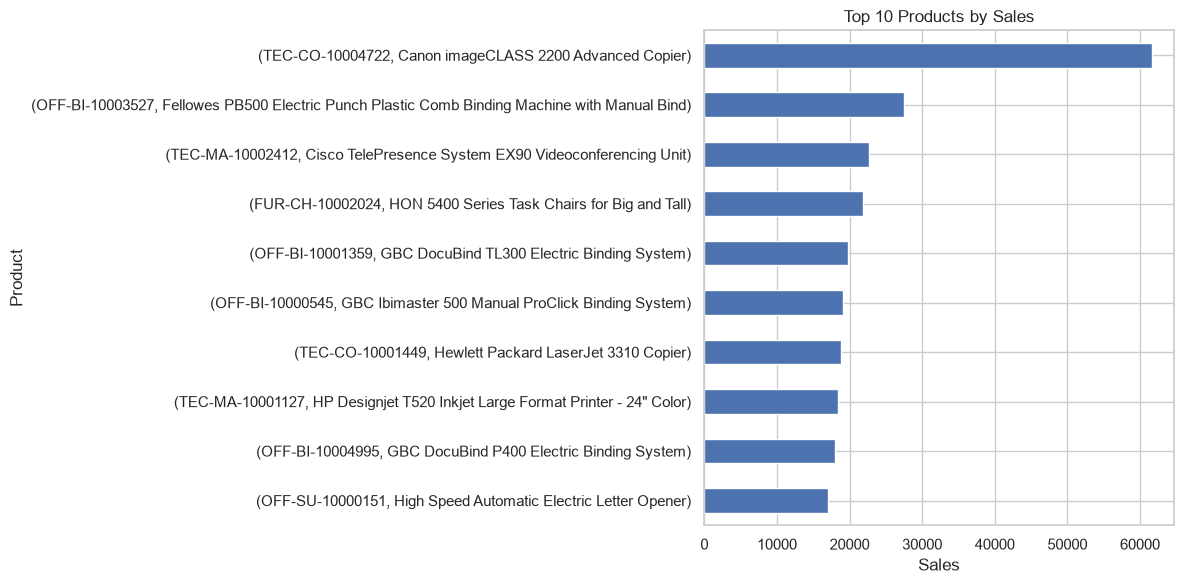

In [20]:
plt.figure(figsize=(12, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

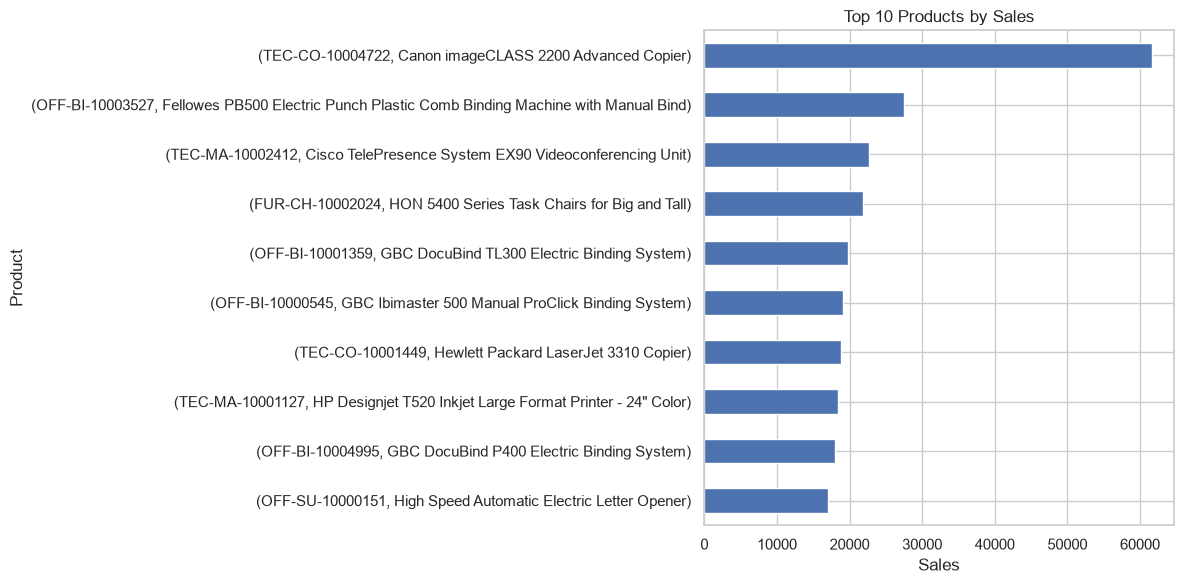

In [21]:
plt.figure(figsize=(12, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [22]:
sales_year = (
    df.groupby("year")["Sales"]
    .sum()
    .sort_index()
)

sales_year

year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

In [23]:
top_customers = (
    df.groupby(["Customer ID", "Customer Name"])["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer ID  Customer Name     
SM-20320     Sean Miller           25043.050
TC-20980     Tamara Chand          19052.218
RB-19360     Raymond Buch          15117.339
TA-21385     Tom Ashbrook          14595.620
AB-10105     Adrian Barton         14473.571
KL-16645     Ken Lonsdale          14175.229
SC-20095     Sanjit Chand          14142.334
HL-15040     Hunter Lopez          12873.298
SE-20110     Sanjit Engle          12209.438
CC-12370     Christopher Conant    12129.072
Name: Sales, dtype: float64

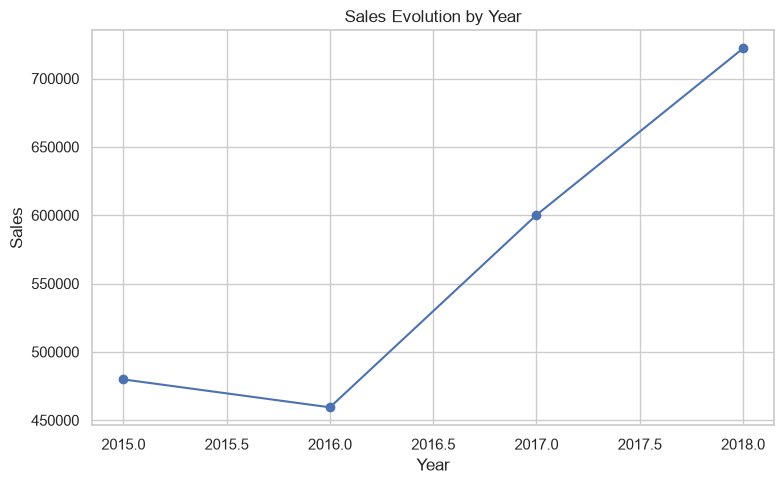

In [24]:
plt.figure(figsize=(8, 5))

sales_year.plot(kind="line", marker="o")

plt.title("Sales Evolution by Year")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [25]:
sales_month = (
    df.groupby(["year", "month"])["Sales"]
    .sum()
    .reset_index()
)

sales_month.head()

,year,month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


In [26]:
shipping_analysis = (
    df.groupby("Ship Mode")
    .agg(
        Orders=("Order ID", "nunique"),
        Average_Shipping_Days=("Shipping Days", "mean"),
        Total_Sales=("Sales", "sum")
    )
    .sort_values("Total_Sales", ascending=False)
)

shipping_analysis

,Orders,Average_Shipping_Days,Total_Sales
Ship Mode,,,
Standard Class,2945,5.008363,1.340831e+06
Second Class,944,3.249211,4.499142e+05
First Class,772,2.179214,3.455723e+05
Same Day,261,0.044610,1.252190e+05


In [27]:
shipping_category = (
    df.groupby("Shipping Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

shipping_category

Shipping Category
Normal    1.314335e+06
Fast      5.473174e+05
Slow      3.998843e+05
Name: Sales, dtype: float64

In [28]:
total_sales = df["Sales"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
total_products = df["Product ID"].nunique()
average_sales = df["Sales"].mean()

print("=" * 50)
print("SUPERSTORE KPI DASHBOARD")
print("=" * 50)

print(f"Total Sales      : ${total_sales:,.2f}")
print(f"Total Orders     : {total_orders:,}")
print(f"Total Customers  : {total_customers:,}")
print(f"Total Products   : {total_products:,}")
print(f"Average Line Sale: ${average_sales:,.2f}")

SUPERSTORE KPI DASHBOARD
Total Sales      : $2,261,536.78
Total Orders     : 4,922
Total Customers  : 793
Total Products   : 1,861
Average Line Sale: $230.77


In [29]:
print("SUPERSTORE ANALYSIS SUMMARY")
print("=" * 50)

print(f"Total sales: ${total_sales:,.2f}")
print(f"Number of orders: {total_orders:,}")
print(f"Number of customers: {total_customers:,}")
print(f"Number of products: {total_products:,}")

print("\nBest category:")
print(sales_category.index[0])

print("\nBest region:")
print(sales_region.index[0])

print("\nBest segment:")
print(sales_segment.index[0])

print("\nTop product:")
print(top_products.index[0][1])

SUPERSTORE ANALYSIS SUMMARY
Total sales: $2,261,536.78
Number of orders: 4,922
Number of customers: 793
Number of products: 1,861

Best category:
Technology

Best region:
West

Best segment:
Consumer

Top product:
Canon imageCLASS 2200 Advanced Copier
